# Normalization and Standardization

`Normalization` and `standardization` are essential `data preprocessing` techniques in machine learning that rescale features to a common scale, preventing variables with larger magnitudes from dominating models.

`Normalization` (`min-max`) scales data to a fixed range (usually 0 to 1). 
`Normalization` is ideal for algorithms that do not assume a distribution, such as `neural networks` (NN) and `k-nearest neighbors` (k-NN). 

`Standardization` (`z-score`) transforms data to have a `mean` of `0` and a `standard deviation` of `1`.
`Standardization` is better suited to handling `outliers` and suiting algorithms assuming `normal distribution` (`Gaussian distribution`), such as `linear regression`. 

Both (`normalization` and `standardization`) are linear transformations (shifting and scaling) of the data. They change the scale, not the structure.

**Why are they important:**  

Without scaling, algorithms that rely on distance metrics (e.g., k-NN, k-means) or gradient descent (e.g., neural networks) will perform poorly because features with large raw values will dominate the distance calculations and model updates.

**Synonym:**

| Normalization         | Standardization         |
| --------------------- | ----------------------- |
| Min-max normalization | z-score standardization |
| Min-max scaling       | z-score scaling         |
|                       | z-score normalization   |

Note: The term `normalization` discussed here is different from the `normalization in physics`, which will be described at last.

## 1. Normalization (Min-max scaling)

**Purpose:**

Scales data to a range, usually \[0, 1\] (or sometimes \[-1, 1\]).

**Formula:**

Suppose we want to normalize the data into the range \[0, 1\], the following formula is used:
$$ x_{new} = \frac{x - x_{min}}{x_{max}-x_{min}} , $$
where $x_{max}$ and $x_{min}$ are the maximum and minimum values of the data, respectively.

**Use Case:**

1. `Bounded data`, e.g., pixel values from 0~255.
2. When data does not follow a normal distribution (Gaussian distribution).
3. When using algorithms that require bounded input.

**Sensitivity:**

Highly sensitive to outliers.

## 2. Standardization (z-score normalization)

**Purpose:**

Centers data around 0 with unit variance (i.e., standard deviation = 1).

**Formula:**

Suppose we want to standardize the data around 0 with unit variance, the following formula is used:
$$ x_{new} = \frac{x - \mu}{\sigma} , $$
where $\mu$ is the mean of the data, and $\sigma$ is the standard deviation of the data.

**Use Case:**

1. Data with `outliers` or distributed close to `Gaussian distributions`.
2. When algorithms assume a `Gaussian distribution` (e.g., `Linear Regression`, `Logistic Regression`, `LDA`).

**Sensitivity:**

Less sensitive to outliers.

## 3. Difference between normalization and standardization

Several differences between normalization and standardization are listed.

| No. | Normalization                        | Standardization                           |
| --- | -------------                        | ---------------                           |
|   1 | Maximum and minimum values are used for scaling | Mean and standard deviation is used for scaling |
|   2 | Used when features are of different scales | Used when we want to ensure zero mean and unit standard deviation |
|   3 | Scales values between \[0, 1\] (or \[-1, 1\]) | It is not bounded to a specific range |
|   4 | Highly affected by outliers | Less affected by outliers |
|   5 | useful when we don't know about the distribution | useful when the feature distribution is normal (Gaussian) |
|   6 | It squishes the *n*-dimensional data into an *n*-dimensional unit hypercube. | It translates the data to the mean vector of the original data to the origin and squishes or expands. |
|   7 | Also called as `scaling normalization` | Also called as `z-score normalization` |
|   8 | `scikit-learn` provides a class [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html). Transform features by scaling each feature to a given range. | `scikit-learn` provides a class [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Standardize features by removing the mean and scaling to unit variance.|

## 4. Example 1 - normalization

Suppose we have a data \[0, 1, 2, ..., 40\], which is ranging from 0 to 40 and equally separated.

First, we calculate the maximum and minimum values of the data, and then normalize the data.

data_max: 40
data_min: 0
data_normal_max: 1.0
data_normal_min: 0.0
data_normal_mean: 0.5
data_normal_std: 0.2958039891549808
dist_normal_data: 0.025


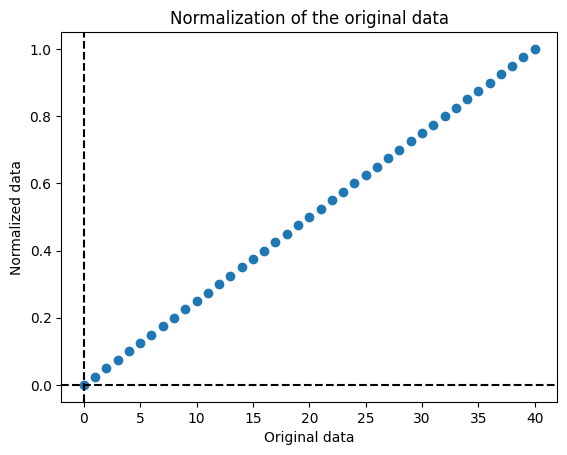

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt

# Create the data
num_data = 40+1
data = np.arange(num_data)

# Calculate the maximum and minimum values of the data
data_max = np.max(data)
print("data_max:", data_max)
data_min = np.min(data)
print("data_min:", data_min)

# Normalization of the data
data_normal = (data - data_min) / (data_max - data_min)
print("data_normal_max:" , np.max(data_normal))
print("data_normal_min:" , np.min(data_normal))
print("data_normal_mean:", np.mean(data_normal))
print("data_normal_std:" , np.std(data_normal))

# Distance from point to point
dist_normal_data = data_normal[1] - data_normal[0]
print("dist_normal_data:", dist_normal_data)

# Plot
plt.scatter(data, data_normal)
plt.axhline(y=0.0, color='k', linestyle='--')
plt.axvline(x=0.0, color='k', linestyle='--')
plt.xlabel("Original data")
plt.ylabel("Normalized data")
plt.title("Normalization of the original data")
plt.show()

The data has been normalized (shifted and scaled) into the range \[0, 1\]. 

As shown in the plot, the point lies on an oblique line with equal point distance, indicating a linear transformation. In other words, the absolute values of the data are changed; however, the data keeps its internal relative structure.

## 5. Example 2 - standardization

Use the same data as shown in example 1.

We calculate the mean and standard deviation of the data, and then standardize the data.

data_mean: 20.0
data_std: 11.832159566199232
data_stand_max: 1.6903085094570331
data_stand_min: -1.6903085094570331
data_stand_mean: 1.624716621402668e-17
data_stand_std: 0.9999999999999999
dist_stand_data: 0.08451542547285174


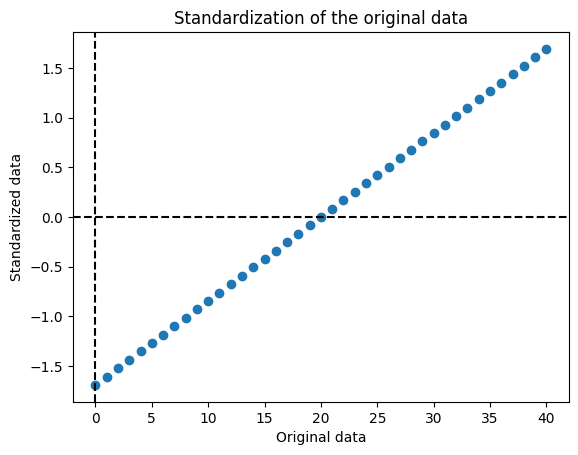

In [2]:
# Calculate the mean and standard deviation of the data
data_mean = np.mean(data)
print("data_mean:", data_mean)
data_std = np.std(data)
print("data_std:", data_std)

# Standardization of the data
data_stand = (data - data_mean) / data_std

print("data_stand_max:" , np.max(data_stand))
print("data_stand_min:" , np.min(data_stand))
print("data_stand_mean:", np.mean(data_stand))
print("data_stand_std:" , np.std(data_stand))

# Distance from point to point
dist_stand_data = data_stand[1] - data_stand[0]
print("dist_stand_data:", dist_stand_data)

# Plot
plt.scatter(data, data_stand)
plt.axhline(y=0.0, color='k', linestyle='--')
plt.axvline(x=0.0, color='k', linestyle='--')
plt.xlabel("Original data")
plt.ylabel("Standardized data")
plt.title("Standardization of the original data")
plt.show()

The data has been standardized (shifted and scaled) into a specific range, making the data have a mean of 0 and unit variance (i.e., standard deviation = 1)

As shown in the plot, the point lies on an oblique line with equal point distance, indicating a linear transformation. In other words, the absolute values of the data are changed; however, the data keeps its internal relative structure.

Both (`normalization` and `standardization`) are linear transformations (shifting and scaling) of the data. They change the scale, not the structure.

## 6. Example 3 - outlier test of normalization

In statistics, an `outlier` is a data point that differs significantly from other observations.

In this example, we add an outlier point far from the original data, and then normalize the data with the outlier.

In [3]:
# Set an outlier
outlier = 80

# Add the outlier to the original data
data_out = np.append(data, outlier)
data_out

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 80])

data_max: 80
data_min: 0
data_out_normal_max: 1.0
data_out_normal_min: 0.0
data_out_normal_mean: 0.26785714285714285
data_out_normal_std: 0.18554823162321812
dist_normal_data_wo_out: 0.0125


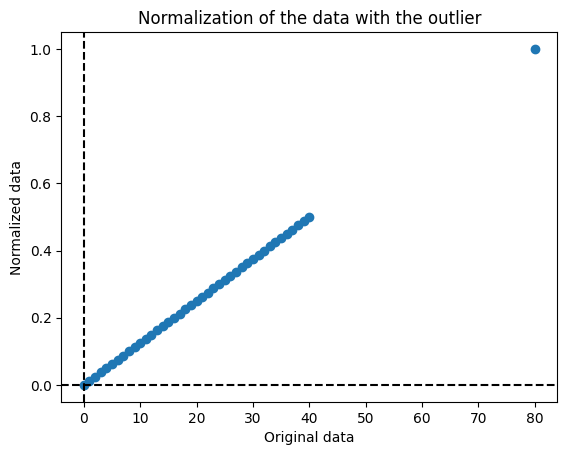

In [4]:
# Calculate the maximum and minimum values of the data
data_out_max = np.max(data_out)
print("data_max:", data_out_max)
data_out_min = np.min(data_out)
print("data_min:", data_out_min)

# Normalization of the data
data_out_normal = (data_out - data_out_min) / (data_out_max - data_out_min)
print("data_out_normal_max:" , np.max(data_out_normal))
print("data_out_normal_min:" , np.min(data_out_normal))
print("data_out_normal_mean:", np.mean(data_out_normal))
print("data_out_normal_std:" , np.std(data_out_normal))

# Distance among the normalized data without the outlier
dist_normal_data_wo_out = data_out_normal[1] - data_out_normal[0]
print("dist_normal_data_wo_out:", dist_normal_data_wo_out)

# Plot
plt.scatter(data_out, data_out_normal)
plt.axhline(y=0.0, color='k', linestyle='--')
plt.axvline(x=0.0, color='k', linestyle='--')
plt.xlabel("Original data")
plt.ylabel("Normalized data")
plt.title("Normalization of the data with the outlier")
plt.show()

The outlier far from the original data is shown on the plot.

The data after normalization remains in the range \[0, 1\].

## 7. Example 4 - outlier test of standardization

We add an outlier point far from the original data, and then standardize the data with the outlier.

data_out_mean: 21.428571428571427
data_out_std: 14.84385852985745
data_out_stand_max: 3.9458358117342587
data_out_stand_min: -1.4435984677076557
data_out_stand_mean: 7.401486830834377e-17
data_out_stand_std: 1.0
dist_stand_data_wo_out: 0.06736792849302398


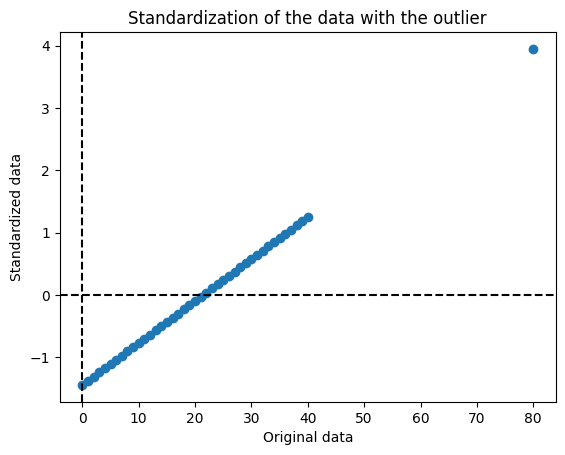

In [5]:
# Calculate the mean and standard deviation of the data
data_out_mean = np.mean(data_out)
print("data_out_mean:", data_out_mean)
data_out_std = np.std(data_out)
print("data_out_std:", data_out_std)

# Standardization of the data
data_out_stand = (data_out - data_out_mean) / data_out_std

print("data_out_stand_max:" , np.max(data_out_stand))
print("data_out_stand_min:" , np.min(data_out_stand))
print("data_out_stand_mean:", np.mean(data_out_stand))
print("data_out_stand_std:" , np.std(data_out_stand))

# Distance among the standardized data without the outlier
dist_stand_data_wo_out = data_out_stand[1] - data_out_stand[0]
print("dist_stand_data_wo_out:", dist_stand_data_wo_out)

# Plot
plt.scatter(data_out, data_out_stand)
plt.axhline(y=0.0, color='k', linestyle='--')
plt.axvline(x=0.0, color='k', linestyle='--')
plt.xlabel("Original data")
plt.ylabel("Standardized data")
plt.title("Standardization of the data with the outlier")
plt.show()

The outlier far from the original data is shown on the plot.

The data after standardization retains the mean of 0 and the standard deviation of 1.

**Comparison of the normalized and standardized data:**

The plots in examples 3 and 4 are almost identical, except for the y-axis vaules.

From a mathematical point of view, the data structure is kept the same under `normalization` and `standardization`, no matter how large (how far) the outlier is. 

**Where is the strange point?**

When the data is put into computer's memory for computing, the story becomes different.

The number is stored with limited resolution, such as `float16`, `float32`, and `float64`. 

If the data distance (spacing) is smaller than the data resolution, we cannot distinguish the data points, resulting in unexpected errors.

## 8. Example 5 - outlier test comparison

Let's discuss when the data distance (spacing) will be smaller than the data resolution.

In this example, we will set a data resolution of value 0.001, and then calculate the data distances of the normalized and standardized data corresponding to outliers of various values.


Destruction condition reached (normalization):
outlier: 1001
dist_normal_data_wo_out: 0.000999000999000999


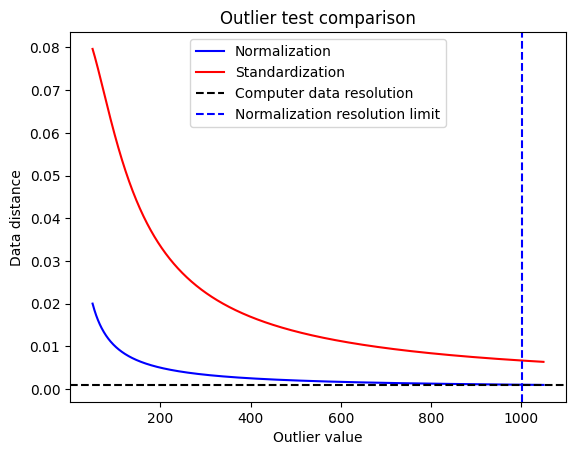

In [6]:
# Set computer data resolution
Data_resolution = 0.001

# Create a data
num_data = 40 + 1
data = np.arange(num_data)

# Create empty array
dist_normal = []
dist_stand  = []
outlier_arr = []

# Critical value consitions
value_condition_normal = False
value_condition_stand  = False

# Initialize critical values
value_dist_normal_destruction = None
value_dist_stand_destruction  = None

for i in range(1000):

    # Set a outlier
    outlier = 50 + i
    
    outlier_arr = np.append(outlier_arr, outlier)    # Record the outlier_arr
    
    # Add the outlier to the original data
    data_out = np.append(data, outlier)

    # Normalization of the data
    data_out_max    = np.max(data_out)
    data_out_min    = np.min(data_out)
    data_out_normal = (data_out - data_out_min) / (data_out_max - data_out_min)

    # Distance among the normalized data without the outlier
    dist_normal_data_wo_out = data_out_normal[1] - data_out_normal[0]
    #print("dist_normal_data_wo_out:", dist_normal_data_wo_out)

    # Record the dist_normal
    dist_normal = np.append(dist_normal, dist_normal_data_wo_out)

    if (dist_normal_data_wo_out < Data_resolution) and (value_condition_normal == False):
        value_dist_normal_destruction = outlier
        print("Destruction condition reached (normalization):")
        print("outlier:", value_dist_normal_destruction)
        print("dist_normal_data_wo_out:", dist_normal_data_wo_out)
        value_condition_normal = True

    # Standardization of the data
    data_out_mean  = np.mean(data_out)
    data_out_std   = np.std(data_out)
    data_out_stand = (data_out - data_out_mean) / data_out_std

    # Distance among the standardized data without the outlier
    dist_stand_data_wo_out = data_out_stand[1] - data_out_stand[0]
    #print("dist_stand_data_wo_out:", dist_stand_data_wo_out)

    # Record the dist_stand
    dist_stand = np.append(dist_stand, dist_stand_data_wo_out)

    if (dist_stand_data_wo_out < Data_resolution) and (value_condition_stand == False):
        value_dist_stand_destruction = outlier
        print("Destruction condition reached (standardization):")
        print("outlier:", value_dist_stand_destruction)
        print("dist_stand_data_wo_out:", dist_stand_data_wo_out)
        value_condition_stand = True

# Plot 
plt.plot(outlier_arr, dist_normal, color="b", label="Normalization")
plt.plot(outlier_arr, dist_stand , color="r", label="Standardization")
plt.axhline(y=Data_resolution, color='k', linestyle='--', label="Computer data resolution")
if value_condition_normal == True:
    plt.axvline(x=value_dist_normal_destruction, color='b', linestyle='--', 
                label="Normalization resolution limit")
if value_condition_stand  == True:
    plt.axvline(x=value_dist_stand_destruction , color='r', linestyle='--', 
                label="Standardization resolution limit")
plt.legend()
plt.xlabel("Outlier value")
plt.ylabel("Data distance")
plt.title("Outlier test comparison")
plt.show()

As shown in the plot, as the value of the outlier approaches 1001 (blue dashed line), the data distance of the normalized data becomes smaller than the data resolution (black dashed line). 

However, the data distance of the standardized data remains fine.

Let's enlarge the value of the outlier until the data distance of the standardized data becomes smaller than the data resolution.

Destruction condition reached (normalization):
outlier: 1001
dist_normal_data_wo_out: 0.000999000999000999
Destruction condition reached (standardization):
outlier: 6579
dist_stand_data_wo_out: 0.0009999770980090028


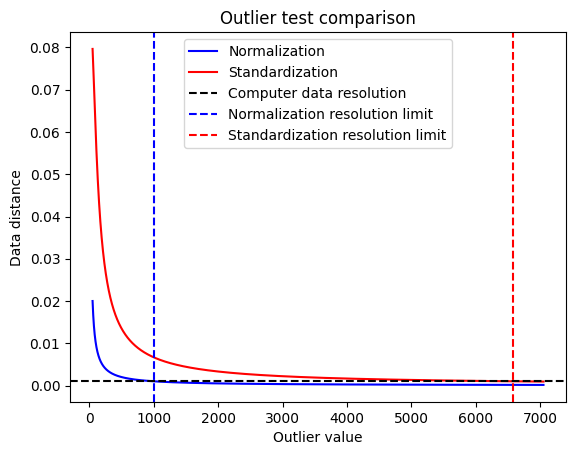

In [7]:
# Set computer data resolution
Data_resolution = 0.001

# Create a data
num_data = 40 + 1
data = np.arange(num_data)

# Create empty array
dist_normal = []
dist_stand  = []
outlier_arr = []

# Critical value consitions
value_condition_normal = False
value_condition_stand  = False

# Initialize critical values
value_dist_normal_destruction = None
value_dist_stand_destruction  = None

for i in range(7000):

    # Set a outlier
    outlier = 50 + i
    
    outlier_arr = np.append(outlier_arr, outlier)    # Record the outlier_arr
    
    # Add the outlier to the original data
    data_out = np.append(data, outlier)

    # Normalization of the data
    data_out_max    = np.max(data_out)
    data_out_min    = np.min(data_out)
    data_out_normal = (data_out - data_out_min) / (data_out_max - data_out_min)

    # Distance among the normalized data without the outlier
    dist_normal_data_wo_out = data_out_normal[1] - data_out_normal[0]
    #print("dist_normal_data_wo_out:", dist_normal_data_wo_out)

    # Record the dist_normal
    dist_normal = np.append(dist_normal, dist_normal_data_wo_out)

    if (dist_normal_data_wo_out < Data_resolution) and (value_condition_normal == False):
        value_dist_normal_destruction = outlier
        print("Destruction condition reached (normalization):")
        print("outlier:", value_dist_normal_destruction)
        print("dist_normal_data_wo_out:", dist_normal_data_wo_out)
        value_condition_normal = True

    # Standardization of the data
    data_out_mean  = np.mean(data_out)
    data_out_std   = np.std(data_out)
    data_out_stand = (data_out - data_out_mean) / data_out_std

    # Distance among the standardized data without the outlier
    dist_stand_data_wo_out = data_out_stand[1] - data_out_stand[0]
    #print("dist_stand_data_wo_out:", dist_stand_data_wo_out)

    # Record the dist_stand
    dist_stand = np.append(dist_stand, dist_stand_data_wo_out)

    if (dist_stand_data_wo_out < Data_resolution) and (value_condition_stand == False):
        value_dist_stand_destruction = outlier
        print("Destruction condition reached (standardization):")
        print("outlier:", value_dist_stand_destruction)
        print("dist_stand_data_wo_out:", dist_stand_data_wo_out)
        value_condition_stand = True

# Plot 
plt.plot(outlier_arr, dist_normal, color="b", label="Normalization")
plt.plot(outlier_arr, dist_stand , color="r", label="Standardization")
plt.axhline(y=Data_resolution, color='k', linestyle='--', label="Computer data resolution")
if value_condition_normal == True:
    plt.axvline(x=value_dist_normal_destruction, color='b', linestyle='--', 
                label="Normalization resolution limit")
if value_condition_stand  == True:
    plt.axvline(x=value_dist_stand_destruction , color='r', linestyle='--', 
                label="Standardization resolution limit")
plt.legend()
plt.xlabel("Outlier value")
plt.ylabel("Data distance")
plt.title("Outlier test comparison")
plt.show()

As shown in the plot, as the value of the outlier approaches 6579 (red dashed line), the data distance of the standardized data becomes smaller than the data resolution (black dashed line).

The simple example has demonstrated the outlier sensitivity of normalization and standardization. The normalized data is much more outlier sensitive than the standardized data, i.e., the normalized data will touch the data resolution limit rapidly (compared to the standardized data).

## 9. Normalization in physics

`Normalization` in physics, particularly in `quantum mechanics`, is the process of `scaling` a `wave function` $\Psi (x, t)$. 

The `total probability` of finding a particle (e.g., electron) in all space equals exactly `1` (`unity`). This ensures that the `probability density` ($\rho = |\Psi (x, t)|^2$) represents a physically meaningful system where the particle must exist somewhere.

**Some major features of normalization in physics:**

1. **Mathematical expression:** The integral of the `probability density` ($\rho$) over all space must be `1`. For a 1D system:  
$$ \int_{-\infty}^{\infty} |\Psi (x, t)|^2 dx = 1 . $$
2. **`Normalization constant`:** If a solution $\Psi (x, t)$ is found, it is multiplied by a constant $A$ such that $A\Psi$ satisfies the `normalization` condition.
3. **Physical relevance:** A wave function must be normalizable to be physically meaningful, meaning the integral of its squared modulus over all space must be `finite` and `non-zero`.
4. **Difference from renormalization:** `Normalization` sets the `total probability` to `1`, whereas `renormalization` is a technique used in `quantum field theory` to handle infinities in calculations.

For example, a `wave function` $\Psi (x, t)$ can be multiplied by a factor to ensure that the `total probability` of finding a particle (e.g., electron) in all space equals exactly `1`, indicating certainty that the particle exists.